# Laboratorio 2 - Problema 3

# Visualización tridimensional de una imagen en escala de grises

## Objetivo

Implementar una función que permita representar una imagen en escala de grises como una superficie tridimensional, donde los ejes X e Y representan la posición espacial de cada píxel y el eje Z representa la intensidad de gris.

## Fundamento teórico

Una imagen en escala de grises puede interpretarse como una matriz bidimensional en la que cada elemento representa la intensidad luminosa de un píxel.

Al representar esta matriz en un espacio tridimensional:

- El eje **X** representa las columnas de la imagen.
- El eje **Y** representa las filas.
- El eje **Z** representa la intensidad del píxel, cuyos valores se encuentran entre 0 y 255.

Esta representación facilita el análisis de cambios de intensidad, relieve de la imagen y variaciones de iluminación.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

## Carga de la imagen

Se carga una imagen a color y posteriormente se convierte a escala de grises para poder representar únicamente la intensidad de cada píxel.

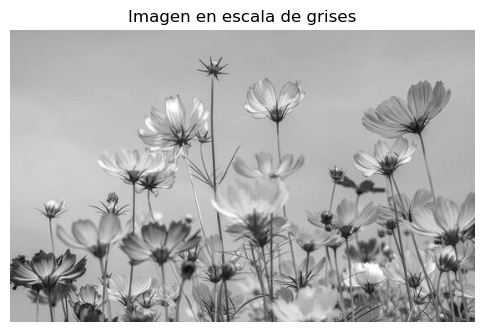

In [2]:
ruta = "../Imagenes lab/4.jpg"

imagen = cv2.imread(ruta)

if imagen is None:
    raise Exception("No fue posible cargar la imagen.")

gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6,6))
plt.imshow(gris, cmap="gray")
plt.title("Imagen en escala de grises")
plt.axis("off")
plt.show()

## Implementación de la función

La siguiente función genera una representación tridimensional utilizando la intensidad de los píxeles como altura sobre el plano XY.

In [3]:
def mostrar_superficie_3d(imagen_gris):

    filas, columnas = imagen_gris.shape

    X, Y = np.meshgrid(
        np.arange(columnas),
        np.arange(filas)
    )

    fig = plt.figure(figsize=(12,8))

    ax = fig.add_subplot(111, projection="3d")

    superficie = ax.plot_surface(
        X,
        Y,
        imagen_gris,
        cmap="gray",
        edgecolor="none"
    )

    ax.set_title("Representación 3D de la imagen")

    ax.set_xlabel("Eje X")
    ax.set_ylabel("Eje Y")
    ax.set_zlabel("Intensidad")

    fig.colorbar(
        superficie,
        shrink=0.6,
        label="Nivel de gris"
    )

    plt.show()

## Visualización tridimensional

Se aplica la función desarrollada para obtener la representación tridimensional de la imagen en escala de grises.

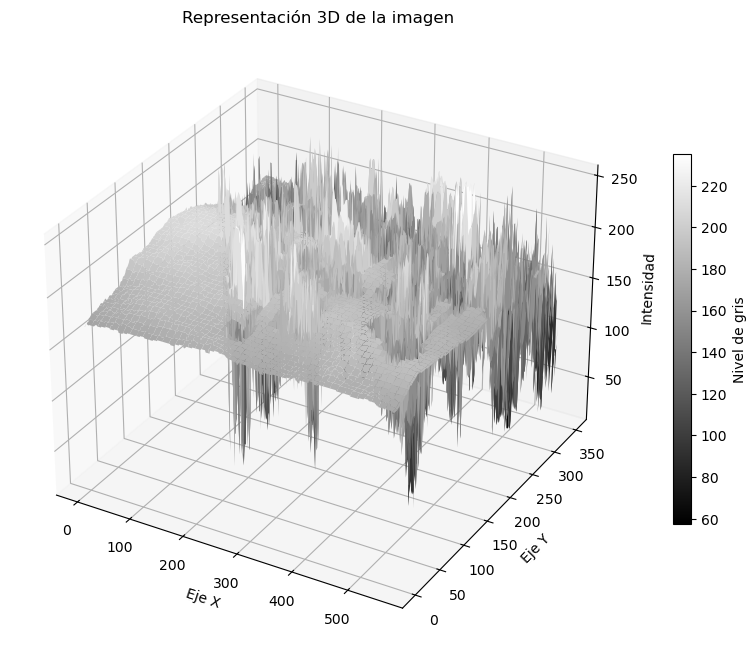

In [4]:
mostrar_superficie_3d(gris)

## Comparación entre la imagen original y su representación tridimensional

Para facilitar la interpretación de los resultados, se presenta la imagen original junto con la superficie tridimensional obtenida.

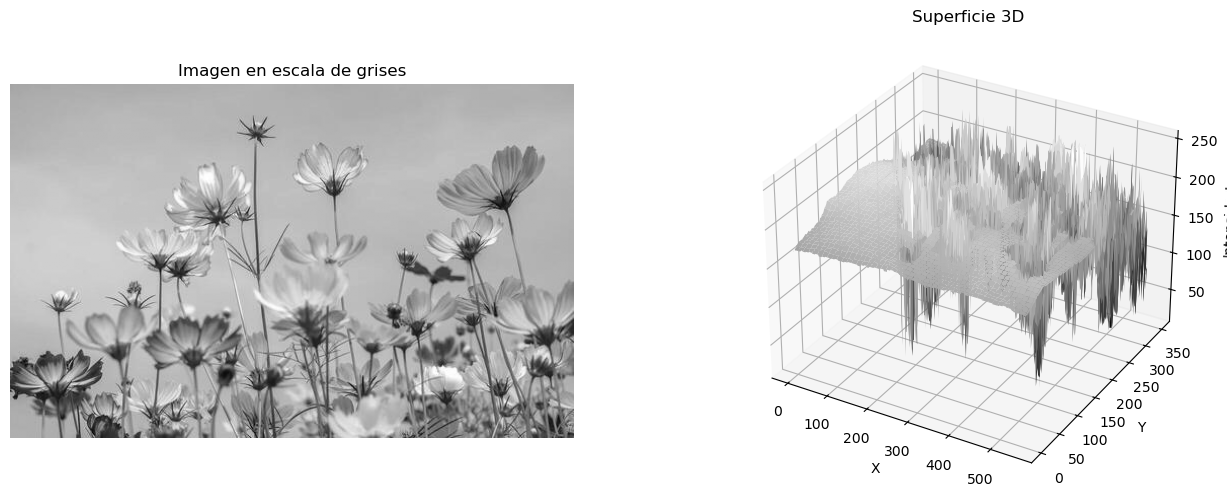

In [5]:
fig = plt.figure(figsize=(16,6))

# Imagen original

ax1 = fig.add_subplot(1,2,1)

ax1.imshow(gris, cmap="gray")

ax1.set_title("Imagen en escala de grises")

ax1.axis("off")

# Superficie

filas, columnas = gris.shape

X, Y = np.meshgrid(
    np.arange(columnas),
    np.arange(filas)
)

ax2 = fig.add_subplot(1,2,2, projection="3d")

ax2.plot_surface(
    X,
    Y,
    gris,
    cmap="gray",
    edgecolor="none"
)

ax2.set_title("Superficie 3D")

ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Intensidad")

plt.show()

## Análisis de resultados

La representación tridimensional permite observar cómo varía la intensidad de los píxeles a lo largo de la imagen.

Las regiones más claras presentan valores de intensidad cercanos a 255 y aparecen como zonas elevadas en la superficie, mientras que las regiones oscuras poseen intensidades cercanas a 0 y se representan como zonas bajas.

Este tipo de visualización resulta útil para el análisis de textura, iluminación y variaciones locales de intensidad.

## Conclusiones

- Una imagen en escala de grises puede interpretarse como una superficie matemática en la que cada píxel representa una altura.
- La representación tridimensional facilita la comprensión de la distribución espacial de las intensidades.
- El uso de Matplotlib permite generar visualizaciones 3D que apoyan el análisis de imágenes en aplicaciones de visión por computadora y procesamiento digital de imágenes.